In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import ruptures as rpt
from arch import arch_model

In [5]:
os.chdir('C:/Users/basleal/Desktop/tutorial/kaim-week-10')

load our data

In [6]:
data = pd.read_csv('data/BrentOilPrices.csv')
data

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63
...,...,...
9006,"Nov 08, 2022",96.85
9007,"Nov 09, 2022",93.05
9008,"Nov 10, 2022",94.25
9009,"Nov 11, 2022",96.37


In [7]:
#convert to time series
data['Date'] = pd.to_datetime(data['Date'])
data=data.sort_values(by='Date')
data= data.set_index('Date')
data['return']= data['Price'].pct_change().dropna()#pct_change calculates the percentage change between concecutive days
#first value is always so we drop it using dropna

C:\Users\basleal\AppData\Local\Temp\ipykernel_14424\2870643622.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


now we see the plot

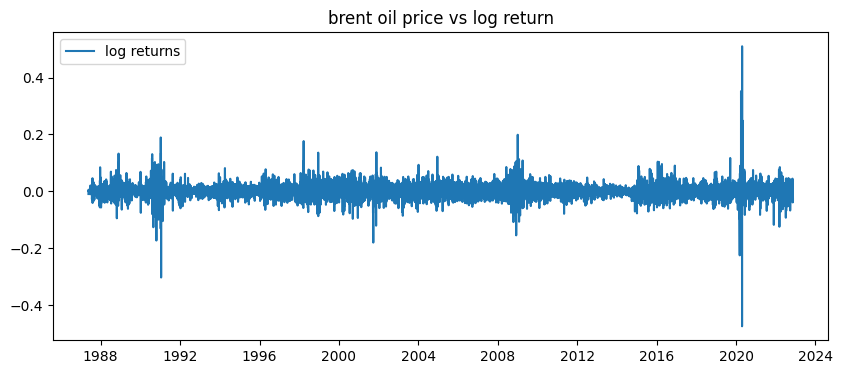

In [8]:
plt.figure(figsize=(10,4))
plt.plot(data['return'],label='log returns')
plt.title("brent oil price vs log return")
plt.legend()
plt.show()



Now we check for volatility clustering

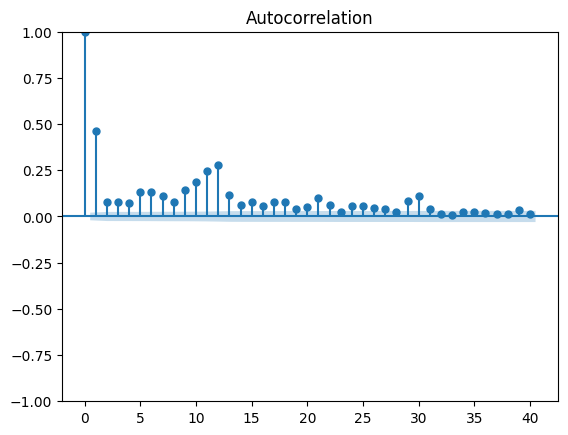

In [9]:
sm.graphics.tsa.plot_acf(data['return'].dropna()**2,lags=40)
plt.show()

we see that there is a volatility clustering here since there are periods where the data is stable followed by fluctuation

let's also test the arch test

In [10]:
from statsmodels.stats.diagnostic import het_arch
arch_test= het_arch(data['return'].dropna())
print('ARCH test p-value: ', arch_test[1])

ARCH test p-value:  0.0


Now we fit a garch model

In [11]:
#define GARCH(1,1) model
garch_model=arch_model(data['return'].dropna(),vol='GARCH',p=1,q=1)
#fit model
garch_fit = garch_model.fit()
print(garch_fit.summary())


Iteration:      1,   Func. Count:      6,   Neg. LLF: 2334841936.069401

c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0006377. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



Iteration:      2,   Func. Count:     18,   Neg. LLF: -22203.304018635485
Optimization terminated successfully    (Exit mode 0)
            Current function value: -22203.30402933981
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                22203.3
Distribution:                  Normal   AIC:                          -44398.6
Method:            Maximum Likelihood   BIC:                          -44370.2
                                        No. Observations:                 9010
Date:                Tue, Feb 25 2025   Df Residuals:                     9009
Time:                        11:32:18   Df Model:                            1
      

Before using our garch model to forecast we should use change point analysis to improve our model

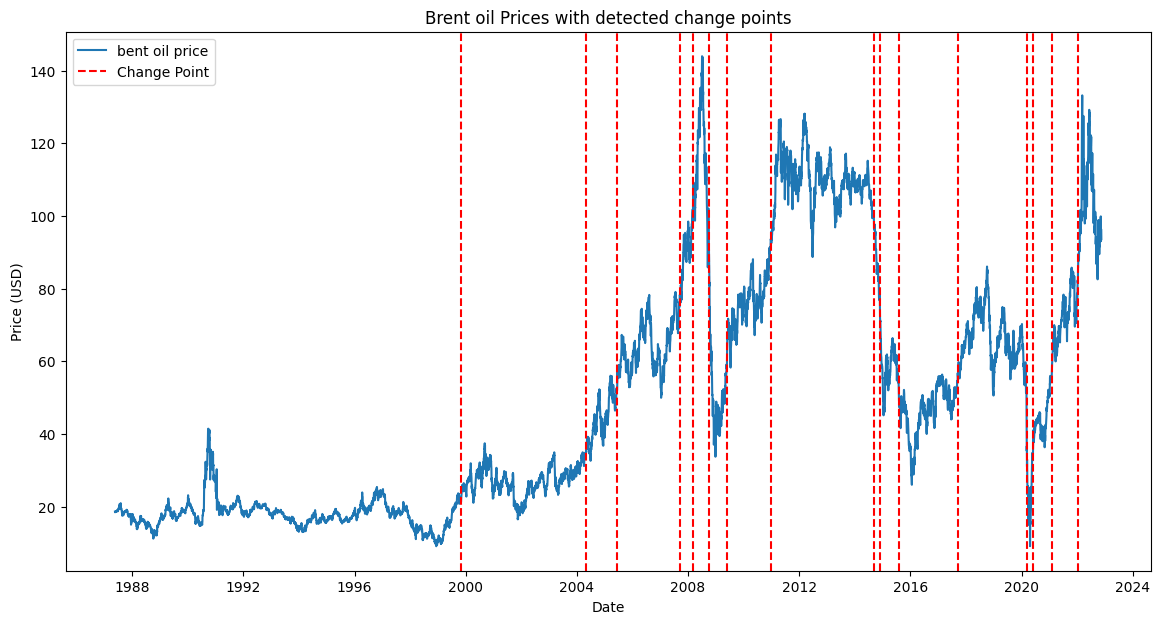

In [12]:
price_array = data['Price'].values
model='rbf'
algo = rpt.Pelt(model=model).fit(price_array)
change_points= algo.predict(pen=20)
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Price'],label = 'bent oil price')
for cp in change_points[:-1]:
    plt.axvline(x=data.index[cp],color='red',linestyle='--',label='Change Point' if cp == change_points[0] else "")
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Brent oil Prices with detected change points')
plt.legend()
plt.show()

now we split our data based on the change point values

In [13]:
change_point =  change_points[:-1]
returns = data['return']*10
returns = returns.dropna()
#split the data into multiple segments
split_returns = [returns[start:end] for start, end in zip([0] + change_points, change_points + [len(returns)])]
split_returns = [segment.dropna() for segment in split_returns]
# Print where the dataset is split
garch_models=[]


for i, segment in enumerate(split_returns):
    print(f"Creating GARCH model for segment {i+1} with {len(segment)} points")

    if len(segment) > 10:  # Ensure enough data
        model = arch_model(segment * 100, vol='Garch', p=1, q=1)  # Rescale data
        fitted_model = model.fit(disp="off")
        garch_models.append(fitted_model)
    else:
        print(f"Segment {i+1} is too short for GARCH modeling...")

# Check if any models were fitted
if garch_models:
    print(garch_models[0].summary())
else:
    print("No GARCH models were fitted. Try adjusting change point detection.")


Creating GARCH model for segment 1 with 3160 points
Creating GARCH model for segment 2 with 1150 points
Creating GARCH model for segment 3 with 290 points
Creating GARCH model for segment 4 with 570 points
Creating GARCH model for segment 5 with 120 points
Creating GARCH model for segment 6 with 150 points
Creating GARCH model for segment 7 with 160 points
Creating GARCH model for segment 8 with 395 points
Creating GARCH model for segment 9 with 930 points
Creating GARCH model for segment 10 with 60 points
Creating GARCH model for segment 11 with 170 points
Creating GARCH model for segment 12 with 545 points
Creating GARCH model for segment 13 with 630 points
Creating GARCH model for segment 14 with 55 points
Creating GARCH model for segment 15 with 175 points


c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.888e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


Creating GARCH model for segment 16 with 240 points
Creating GARCH model for segment 17 with 210 points
Creating GARCH model for segment 18 with 0 points
Segment 18 is too short for GARCH modeling...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13828.1
Distribution:                  Normal   AIC:                           27664.2
Method:            Maximum Likelihood   BIC:                           27688.5
                                        No. Observations:                 3160
Date:                Tue, Feb 25 2025   Df Residuals:                     3159
Time:                        11:36:51   Df Model:                            1
                               Mean Model                               
                

so we segmented our dataset into 17 segments using change points now we can make predictions on them

In [14]:
print(change_points)

[3160, 4310, 4600, 5170, 5290, 5440, 5600, 5995, 6925, 6985, 7155, 7700, 8330, 8385, 8560, 8800, 9011]


In [15]:
print(garch_models[0].summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13828.1
Distribution:                  Normal   AIC:                           27664.2
Method:            Maximum Likelihood   BIC:                           27688.5
                                        No. Observations:                 3160
Date:                Tue, Feb 25 2025   Df Residuals:                     3159
Time:                        11:36:51   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2736      0.297      0.921      0.357 [ -0.309,  0.85

Next is evaluation of our models

we can do this using several methods, we can check for residuals

Plot residuals

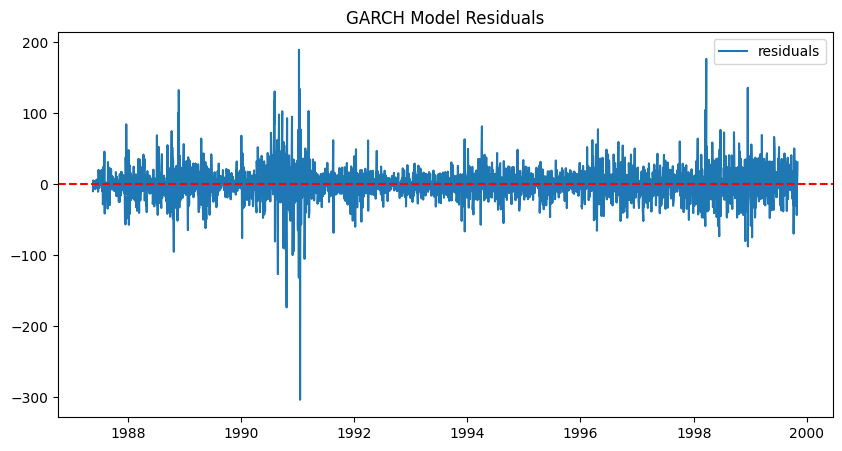

In [16]:
plt.figure(figsize=(10,5))
plt.plot(garch_models[0].resid,label="residuals")
plt.axhline(0,color='red',linestyle='--')
plt.legend()
plt.title("GARCH Model Residuals")
plt.show()

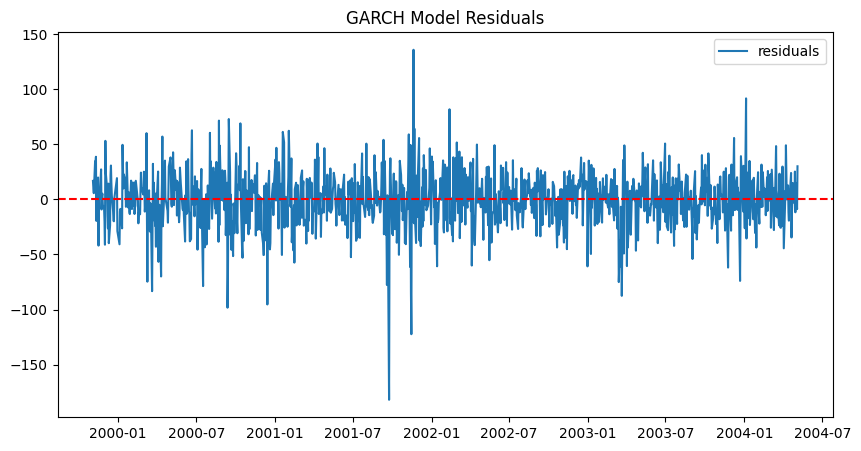

In [17]:
plt.figure(figsize=(10,5))
plt.plot(garch_models[1].resid,label="residuals")
plt.axhline(0,color='red',linestyle='--')
plt.legend()
plt.title("GARCH Model Residuals")
plt.show()

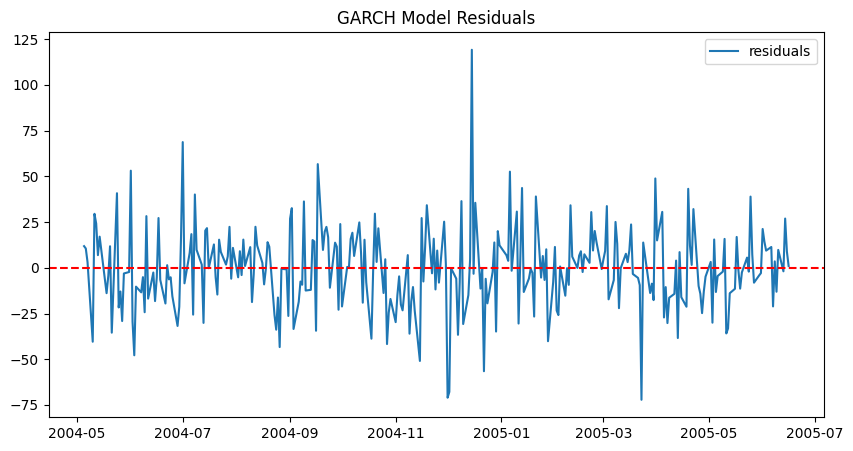

In [18]:
plt.figure(figsize=(10,5))
plt.plot(garch_models[2].resid,label="residuals")
plt.axhline(0,color='red',linestyle='--')
plt.legend()
plt.title("GARCH Model Residuals")
plt.show()

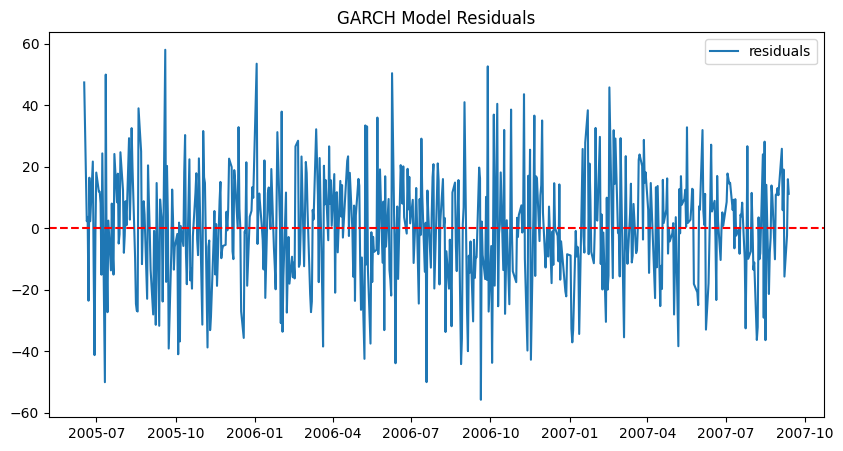

In [19]:
plt.figure(figsize=(10,5))
plt.plot(garch_models[3].resid,label="residuals")
plt.axhline(0,color='red',linestyle='--')
plt.legend()
plt.title("GARCH Model Residuals")
plt.show()

As expected the residuals are normally distributed

checking using ljung box test(autocorrelation test)

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test=acorr_ljungbox(garch_models[1].resid.dropna(),lags=[10],return_df=True)
lb_test

,lb_stat,lb_pvalue
10,5.710624,0.838961


In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

# Store results for all models
lb_test_results = []

# Loop through all GARCH models
for i, model in enumerate(garch_models):
    if model is not None:  # Ensure the model exists (some segments may be too short)
        lb_test = acorr_ljungbox(model.resid.dropna(), lags=[10], return_df=True)
        lb_test['Segment'] = i + 1  # Add segment number
        lb_test_results.append(lb_test)

# Combine results into a single DataFrame
lb_test_df = pd.concat(lb_test_results, ignore_index=True)

# Display the results
print(lb_test_df)


      lb_stat  lb_pvalue  Segment
0   32.118735   0.000383        1
1    5.710624   0.838961        2
2   16.311605   0.091053        3
3    7.766359   0.651647        4
4   15.202861   0.124839        5
5   15.844028   0.104185        6
6   13.433533   0.200432        7
7    5.460431   0.858379        8
8    7.035518   0.722088        9
9   12.934019   0.227384       10
10  19.878169   0.030426       11
11   5.945005   0.819862       12
12   9.308479   0.503099       13
13  16.073457   0.097549       14
14  13.494408   0.197327       15
15  10.472205   0.400086       16
16  17.882802   0.056973       17


Averaging the pvalue

In [22]:
pvalue_overall = lb_test_df['lb_pvalue'].mean()
pvalue_overall

np.float64(0.3485101803146163)

pvalue > 0.05 meaning that the residuals do not have significant autocorrelation (good model fit)

Next we evaluate our model with different metrics

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [24]:
# Store evaluation metrics
garch_results = []
for i, model in enumerate(garch_models):
    if model is not None:
        #get predicted variance
        forecast = model.forecast(start = 0)
        pred_volatility=np.sqrt(forecast.variance.iloc[-1])#last predicted variance
        #get residuals
        residuals = model.resid.dropna()
        #compute metrics
        aic = model.aic
        bic = model.bic
        rmse = np.sqrt(mean_squared_error(residuals, np.zeros_like(residuals)))
        mae = mean_absolute_error(residuals, np.zeros_like(residuals))#mean absolute error
        #store errors
        garch_results.append({"segment":i+1, 'AIC':aic,"BIC":bic,"RMSE":rmse,"MAE":mae,'pred_volatility':pred_volatility})
garch_results_df = pd.DataFrame(garch_results)
garch_results_df

,segment,AIC,BIC,RMSE,MAE,pred_volatility
0,1,27664.235404,27688.468713,22.878854,15.332984,"h.1 25.818778 Name: 1999-11-02 00:00:00, dt..."
1,2,10603.731805,10623.921874,25.183546,18.770554,"h.1 21.670433 Name: 2004-05-04 00:00:00, dt..."
2,3,2637.900455,2652.579979,22.718355,16.986035,"h.1 19.829624 Name: 2005-06-16 00:00:00, dt..."
3,4,4972.778797,4990.161343,18.897081,14.916320,"h.1 17.686727 Name: 2007-09-12 00:00:00, dt..."
4,5,1044.735159,1055.885126,18.219199,14.206106,"h.1 18.471259 Name: 2008-03-06 00:00:00, dt..."
5,6,1386.836169,1398.878711,24.648361,18.132867,"h.1 29.266305 Name: 2008-10-08 00:00:00, dt..."
6,7,1673.306430,1685.607125,46.024136,33.814062,"h.1 23.377341 Name: 2009-05-29 00:00:00, dt..."
7,8,3475.179078,3491.094621,20.026718,15.678127,"h.1 11.457421 Name: 2010-12-21 00:00:00, dt..."
8,9,7391.150813,7410.491551,13.618993,10.012683,"h.1 8.342153 Name: 2014-09-08 00:00:00, dty..."
9,10,494.312694,502.690072,14.907772,10.688975,"h.1 18.238864 Name: 2014-12-02 00:00:00, dt..."


In [25]:
summary_metrics=garch_results_df[["AIC","BIC","RMSE","MAE"]].mean()
summary_metrics

AIC     4701.893750
BIC     4716.666750
RMSE      30.080615
MAE       21.550839
dtype: float64

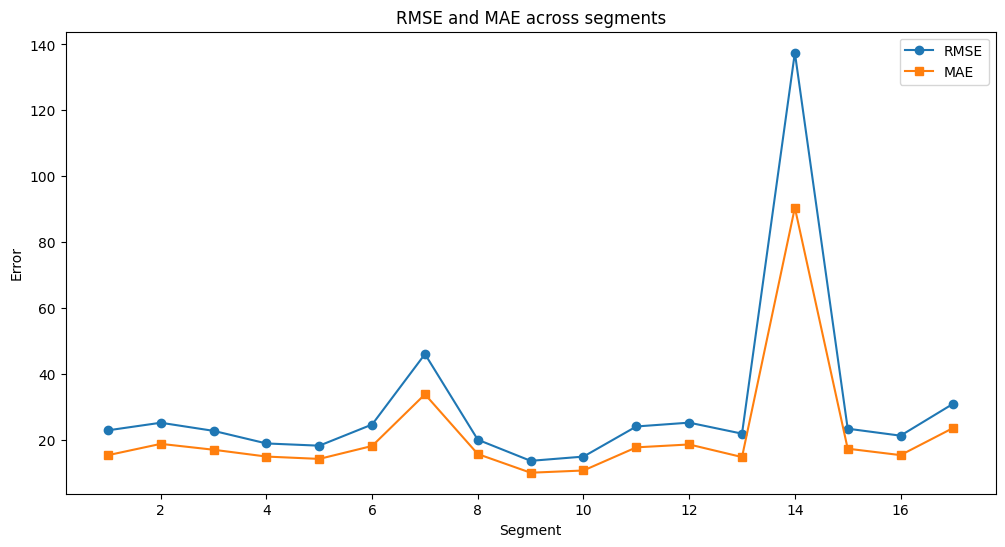

In [26]:
import matplotlib.pyplot as plt

# Plot RMSE and MAE for each segment
plt.figure(figsize=(12,6))
plt.plot(garch_results_df["segment"], garch_results_df["RMSE"], marker="o", label="RMSE")
plt.plot(garch_results_df["segment"], garch_results_df["MAE"], marker="s", label="MAE")
plt.xlabel("Segment")
plt.ylabel("Error")
plt.legend()
plt.title("RMSE and MAE across segments")
plt.show()

c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\basleal\Desktop\tutorial\kaim-week-10\venv\Lib\site-packages\matplotlib\cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


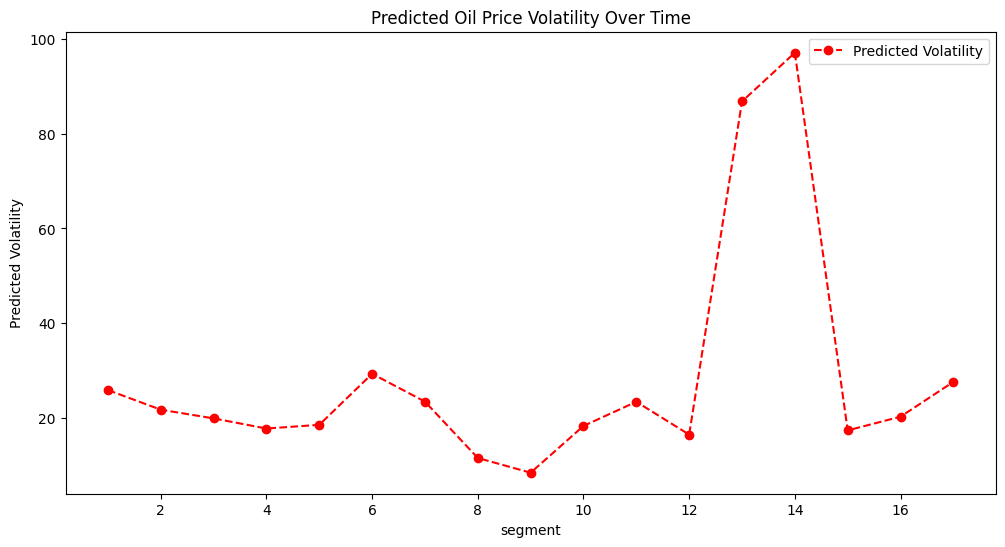

In [27]:
plt.figure(figsize=(12,6))
plt.plot(garch_results_df["segment"], garch_results_df["pred_volatility"], marker="o", linestyle="--", color="red", label="Predicted Volatility")
plt.xlabel("segment")
plt.ylabel("Predicted Volatility")
plt.title("Predicted Oil Price Volatility Over Time")
plt.legend()
plt.show()

Now we download external factors and merge them with our datas

we can use Python to fetch real-time data from sources like the World Bank, FRED, or IMF

In [33]:
import pandas_datareader.data as web
from datetime import datetime
import wbdata

In [45]:
#fetch GDP growth rate from world Bank (indicator)
indicator={'NY.GDP.MKTP.CD':'GDP'}
#define data range
start_date='1987'
end_date = '2022'
#fetch data
gdp_data =  wbdata.get_dataframe(indicator, date=(start_date, end_date))
gdp_data = gdp_data.reset_index()
gdp_data

,country,date,GDP
0,Africa Eastern and Southern,2022,1.191423e+12
1,Africa Eastern and Southern,2021,1.085745e+12
2,Africa Eastern and Southern,2020,9.333918e+11
3,Africa Eastern and Southern,2019,1.009721e+12
4,Africa Eastern and Southern,2018,1.012306e+12
...,...,...,...
9571,Zimbabwe,1991,8.641482e+09
9572,Zimbabwe,1990,8.783817e+09
9573,Zimbabwe,1989,8.286323e+09
9574,Zimbabwe,1988,7.814784e+09


In [46]:
gdp_data.to_csv('wb_gdp.csv')